In [33]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from prophet import Prophet
from io import BytesIO
from fpdf import FPDF

# 2. Load Dataset


df = pd.read_csv("sales_data.csv", encoding="latin1")
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Order Date'] = pd.to_datetime(df['Order Date'], format="mixed", dayfirst=True, errors='coerce')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Profit Margin'] = df['Profit'] / df['Sales']

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Profit Margin
0,1,CA-2013-152156,2013-11-09,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2013,11,0.1600
1,2,CA-2013-152156,2013-11-09,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2013,11,0.3000
2,3,CA-2013-138688,2013-06-13,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2013,6,0.4700
3,4,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2012,10,-0.4000
4,5,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2012,10,0.1125


In [34]:
# -----------------------------
# 3. KPIs (Key Performance Indicators)
# -----------------------------
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_margin = df['Profit Margin'].mean()

print(f"Total Sales: ${total_sales:,.0f}")
print(f"Total Profit: ${total_profit:,.0f}")
print(f"Average Profit Margin: {avg_margin:.2%}")


Total Sales: $2,297,201
Total Profit: $286,397
Average Profit Margin: 12.03%


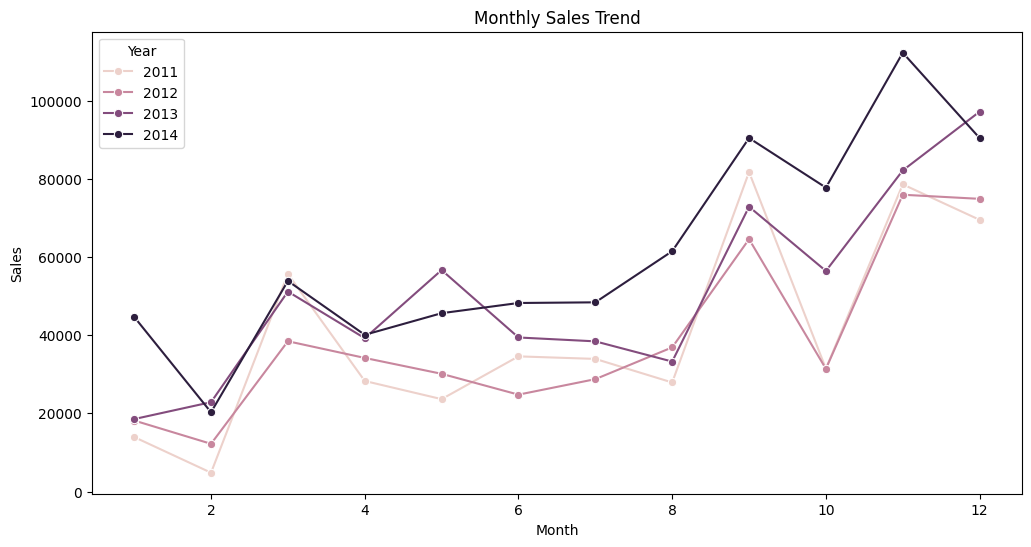

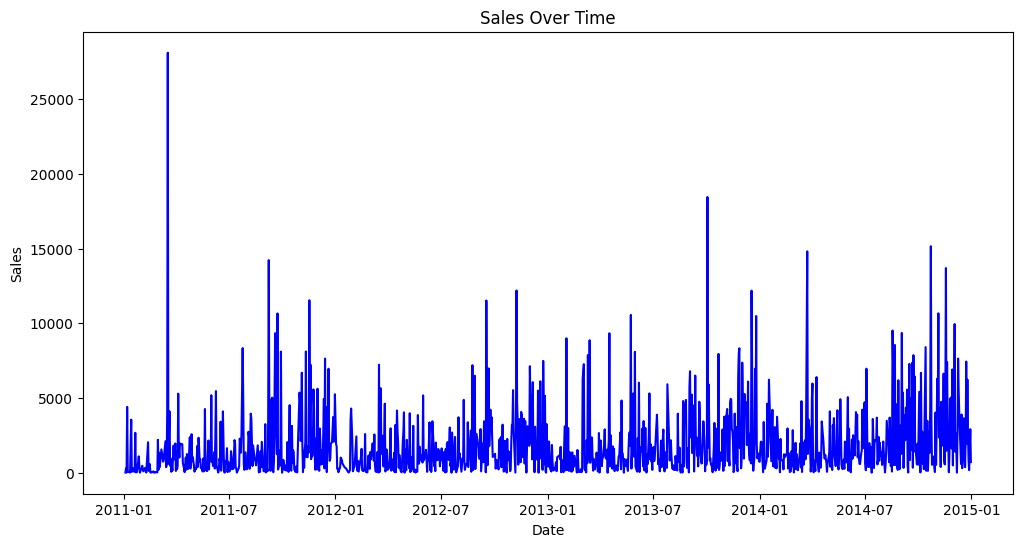

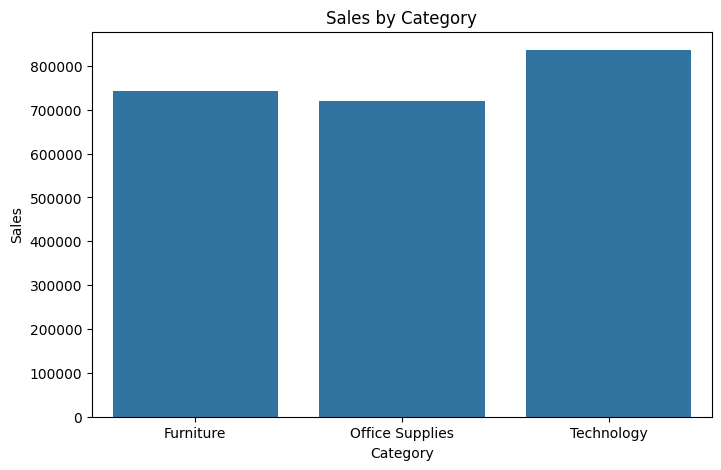

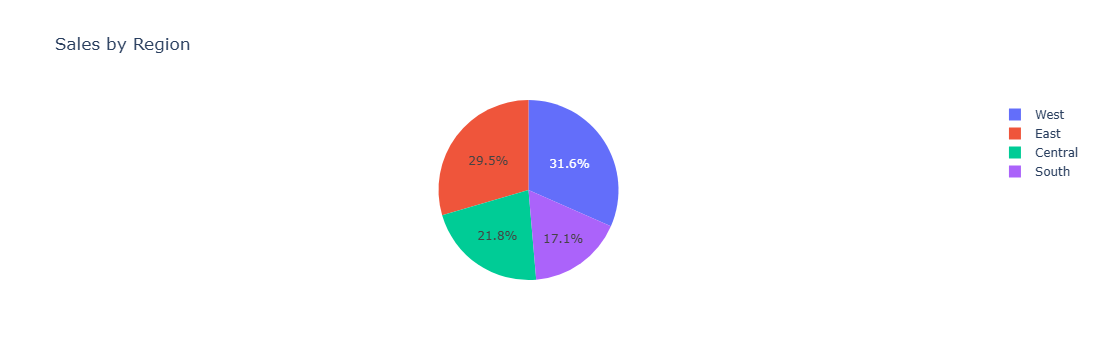

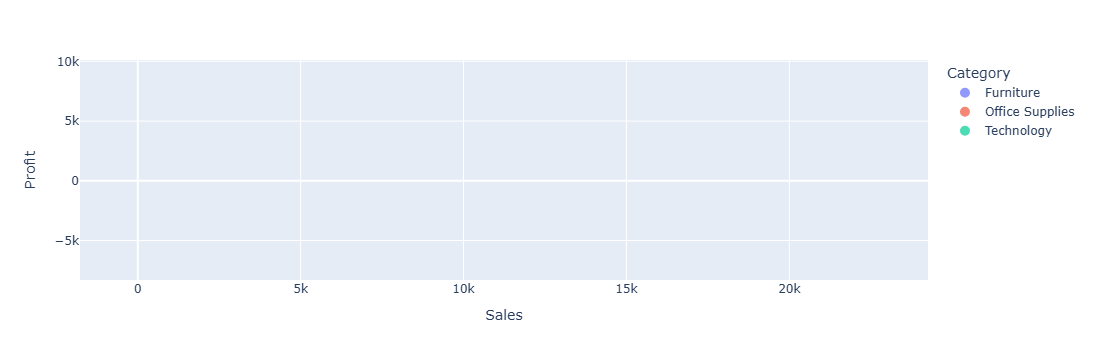

In [38]:
# -----------------------------
# 4. Data Visualization
# -----------------------------

# Monthly Sales Trend
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', marker="o")
plt.title("Monthly Sales Trend")
plt.show()


# Sales Trend
sales_trend = df.groupby('Order Date')['Sales'].sum().reset_index()
plt.figure(figsize=(12,6))
plt.plot(sales_trend['Order Date'], sales_trend['Sales'], color='blue')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Sales by Category
plt.figure(figsize=(8,5))
sns.barplot(x=df['Category'], y=df['Sales'], estimator=sum, errorbar=None)
plt.title("Sales by Category")
plt.show()

# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
fig = px.pie(region_sales, names='Region', values='Sales', title="Sales by Region")
fig.show()

# Profit vs Sales Scatter
fig = px.scatter(df, x="Sales", y="Profit", size="Quantity", color="Category",
                 hover_data=['Product Name'])
fig.show()


14:08:26 - cmdstanpy - INFO - Chain [1] start processing
14:08:26 - cmdstanpy - INFO - Chain [1] done processing


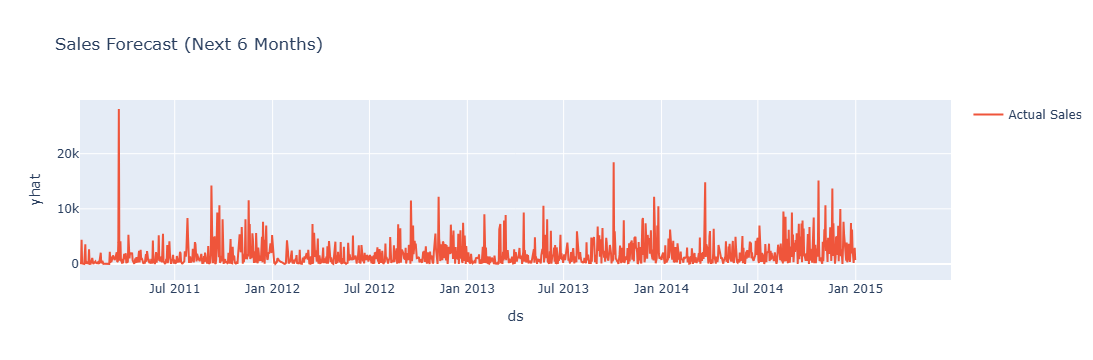

In [37]:
# -----------------------------
# 5. Sales Forecasting (Prophet)
# -----------------------------
forecast_df = df.groupby('Order Date')['Sales'].sum().reset_index()
forecast_df = forecast_df.rename(columns={"Order Date": "ds", "Sales": "y"})

model = Prophet()
model.fit(forecast_df)

future = model.make_future_dataframe(periods=180)  # 6 months ahead
forecast = model.predict(future)

fig = px.line(forecast, x='ds', y='yhat', title="Sales Forecast (Next 6 Months)")
fig.add_scatter(x=forecast_df['ds'], y=forecast_df['y'], mode='lines', name="Actual Sales")
fig.show()


In [27]:
# -----------------------------
# 6. Export Reports
# -----------------------------

# Export to Excel
with pd.ExcelWriter("sales_report.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, index=False, sheet_name="Sales Data")
print("✅ Excel report saved as sales_report.xlsx")

# Export to PDF (Summary only)
def create_pdf_report(df, total_sales, total_profit, avg_margin):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)

    pdf.cell(200, 10, txt="Sales Data Analysis Report", ln=True, align="C")
    pdf.ln(10)
    pdf.cell(200, 10, txt=f"Total Sales: ${total_sales:,.0f}", ln=True)
    pdf.cell(200, 10, txt=f"Total Profit: ${total_profit:,.0f}", ln=True)
    pdf.cell(200, 10, txt=f"Average Profit Margin: {avg_margin:.2%}", ln=True)

    pdf.output("sales_report.pdf")

create_pdf_report(df, total_sales, total_profit, avg_margin)
print("✅ PDF report saved as sales_report.pdf")


✅ Excel report saved as sales_report.xlsx
✅ PDF report saved as sales_report.pdf


In [29]:
# -----------------------------
# 7. Automated Insights Summary
# -----------------------------
top_category = df.groupby("Category")['Sales'].sum().idxmax()
top_region = df.groupby("Region")['Sales'].sum().idxmax()
most_profitable = df.groupby("Product Name")['Profit'].sum().idxmax()

insights = f"""
- 📈 Total Sales reached ${total_sales:,.0f}, with overall Profit of ${total_profit:,.0f}.
- 🏆 The {top_category} category generated the highest sales.
- 🌍 The {top_region} region contributed the most revenue.
- 💡 The most profitable product was {most_profitable}.
- ⚖️ Average Profit Margin stands at {avg_margin:.2%}.
"""

print(insights)



- 📈 Total Sales reached $2,297,201, with overall Profit of $286,397.
- 🏆 The Technology category generated the highest sales.
- 🌍 The West region contributed the most revenue.
- 💡 The most profitable product was Canon imageCLASS 2200 Advanced Copier.
- ⚖️ Average Profit Margin stands at 12.03%.

